# Machine Learning Model on Refugee Population Forecasting and Humanitarian Resource Planning System for Kenya
___
**Team**: XG BOOST BUSTERS  
**Contributors**: Cynthia Jemutai, Stephen Jilani, Charity Nduati,Joy Njeru , Chris Karagu , Sylvia  Wambui

**Project**: Phase 5 Capstone Project   
**Data Sources**: [Kenya Refugee and Asylum Population Dataset](https://www..com/)
___

### 1. Introduction

Kenya accommodates populations displaced by conflict, persecution, climate shocks, and political instability originating from across the region including Somalia, South Sudan, the Democratic Republic of Congo, Ethiopia, Burundi, and Rwanda, among 39 origin countries identified in this dataset.

Several organizations work together to support refugees in Kenya:
1. Department of Refugee Services (DRS): The Kenyan government agency responsible for refugee registration, camp management, policy implementation, and ensuring compliance with the Refugee Act of 2021.
2. United Nations High Commissioner for Refugees (UNHCR): Coordinates the overall refugee response, manages refugee registration and data, mobilizes international funding, and promotes refugee protection.
3. World Food Programme (WFP): Provides food assistance through food distribution and Cash and Voucher Assistance (CVA) programmes to improve food security.
4. Kenya Red Cross Society (KRCS): Delivers frontline humanitarian services, including emergency medical care, disaster response, water supply, family tracing, and support for new refugee arrivals at border entry points.

Together, these organizations form an integrated humanitarian system that provides protection, food, healthcare, and essential services to refugees across Kenya.

### 2. Problem Statement

Kenya hosts one of the largest refugee populations in sub-Saharan Africa, making effective humanitarian planning essential. However, resource planning is often based on current or historical population data rather than future forecasts, limiting preparedness for sudden increases in refugee arrivals.

Key challenges identified from the HDX HAPI dataset include:

1. Rapid population changes that increase demand for food, healthcare, shelter, and other essential services.
2. Diverse demographic groups with different ages, genders, and vulnerabilities that require tailored support.
3. Different population categories (e.g., refugees and asylum seekers) with distinct humanitarian needs.
4. Delays in resource deployment, making it difficult to respond quickly to population surges.
5. Limited use of historical data for forecasting despite decades of available records.

These challenges highlight the need for a machine learning-based forecasting approach to support better resource planning and decision-making for refugee assistance in Kenya.

### 3. Project Objectives

#### 3.1 Primary Objective


To design, develop, and validate a machine learning forecasting system that predicts Kenya's refugee and asylum-seeker population levels disaggregated by origin country, population group, gender, and age cohort with a forecasting horizon of 6 to 24 months, and to translate these forecasts into quantified humanitarian resource planning recommendations.

#### 3.2 Specific Objectives 


1. Explore the HDX HAPI Kenya dataset to identify population trends, demographic patterns, and changes over time.
2. Create relevant features to improve forecasting performance.
3. Develop and compare forecasting models to predict refugee population trends.
4. Generate population forecasts by refugee category, age, gender, and country of origin.
5. Estimate humanitarian resource needs based on the forecasted population.
6. Evaluate model performance using standard forecasting metrics (RMSE, MAE, and MAPE).
7. Provide recommendations to support data-driven humanitarian planning and decision-making in Kenya.

### Data Understanding


The HDX HAPI dataset covers 25 years (2001–2025) with 27,664 records across four population groups: Refugees (REF), Asylum Seekers (ASY), Host Community (HST), and Others of Concern (OOC) disaggregated by gender and five age cohorts.
population count.
les



*Target Variable*
Population
The total refugee/asylum population count.

## 4. Loading of Data  and relevant Libraries

In [61]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [62]:
#load data
df = pd.read_csv("Kenya_Refugee.csv")
df.head()

,origin_location_code,origin_has_hrp,origin_in_gho,asylum_location_code,asylum_has_hrp,asylum_in_gho,population_group,gender,age_range,min_age,max_age,population,reference_period_start,reference_period_end
0,AFG,True,True,KEN,False,True,ASY,f,0-4,0.0,4.0,0,2020-01-01,2020-12-31
1,AFG,True,True,KEN,False,True,ASY,f,5-11,5.0,11.0,0,2020-01-01,2020-12-31
2,AFG,True,True,KEN,False,True,ASY,f,12-17,12.0,17.0,0,2020-01-01,2020-12-31
3,AFG,True,True,KEN,False,True,ASY,f,18-59,18.0,59.0,0,2020-01-01,2020-12-31
4,AFG,True,True,KEN,False,True,ASY,f,60+,60.0,NaN,0,2020-01-01,2020-12-31


## Data overview

In [63]:
#total rows and columns
df.shape

(27664, 14)

In [64]:
#list columns
df.columns.tolist()

['origin_location_code',
 'origin_has_hrp',
 'origin_in_gho',
 'asylum_location_code',
 'asylum_has_hrp',
 'asylum_in_gho',
 'population_group',
 'gender',
 'age_range',
 'min_age',
 'max_age',
 'population',
 'reference_period_start',
 'reference_period_end']

*dataset has 27,664 rows and 15 columns*

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27664 entries, 0 to 27663
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   origin_location_code    27664 non-null  object 
 1   origin_has_hrp          27664 non-null  bool   
 2   origin_in_gho           27664 non-null  bool   
 3   asylum_location_code    27664 non-null  object 
 4   asylum_has_hrp          27664 non-null  bool   
 5   asylum_in_gho           27664 non-null  bool   
 6   population_group        27664 non-null  object 
 7   gender                  27664 non-null  object 
 8   age_range               27664 non-null  object 
 9   min_age                 21280 non-null  float64
 10  max_age                 17024 non-null  float64
 11  population              27664 non-null  int64  
 12  reference_period_start  27664 non-null  object 
 13  reference_period_end    27664 non-null  object 
dtypes: bool(4), float64(2), int64(1), obje

*dataset has a mix of categorical and numerical data*
*we notice no missing values*

# Descriptive statistics 

In [66]:
df.describe()

,min_age,max_age,population
count,21280.00000,17024.00000,27664.000000
mean,19.00000,22.75000,1409.757591
std,21.39209,21.42929,13881.284560
min,0.00000,4.00000,0.000000
25%,5.00000,9.25000,0.000000
50%,12.00000,14.00000,0.000000
75%,18.00000,27.50000,17.000000
max,60.00000,59.00000,517666.000000


## 5. Data Cleaning

In [67]:

#filtering the data set to have only data  for refugees who took  assylum in kenya
df = df[df['asylum_location_code']=='KEN']
df

,origin_location_code,origin_has_hrp,origin_in_gho,asylum_location_code,asylum_has_hrp,asylum_in_gho,population_group,gender,age_range,min_age,max_age,population,reference_period_start,reference_period_end
0,AFG,True,True,KEN,False,True,ASY,f,0-4,0.0,4.0,0,2020-01-01,2020-12-31
1,AFG,True,True,KEN,False,True,ASY,f,5-11,5.0,11.0,0,2020-01-01,2020-12-31
2,AFG,True,True,KEN,False,True,ASY,f,12-17,12.0,17.0,0,2020-01-01,2020-12-31
3,AFG,True,True,KEN,False,True,ASY,f,18-59,18.0,59.0,0,2020-01-01,2020-12-31
4,AFG,True,True,KEN,False,True,ASY,f,60+,60.0,NaN,0,2020-01-01,2020-12-31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27659,ZWE,False,False,KEN,False,True,REF,m,12-17,12.0,17.0,0,2025-01-01,2025-12-31
27660,ZWE,False,False,KEN,False,True,REF,m,18-59,18.0,59.0,0,2025-01-01,2025-12-31
27661,ZWE,False,False,KEN,False,True,REF,m,60+,60.0,NaN,0,2025-01-01,2025-12-31
27662,ZWE,False,False,KEN,False,True,REF,m,all,NaN,NaN,8,2025-01-01,2025-12-31


In [68]:
#missing values
print('Missing values per column:')
print(df.isnull().sum())
print('\n')
#duplicate 
print('Duplicate :', df.duplicated().sum())

Missing values per column:
origin_location_code         0
origin_has_hrp               0
origin_in_gho                0
asylum_location_code         0
asylum_has_hrp               0
asylum_in_gho                0
population_group             0
gender                       0
age_range                    0
min_age                   2562
max_age                   4270
population                   0
reference_period_start       0
reference_period_end         0
dtype: int64


Duplicate : 0


In [69]:
#we noticed that the all column was a  addition of the males and female which would lead to duplication
#drop 'all' on gender
df = df[df['gender'] != 'all']
print(df['gender'].unique())

['f' 'm']


The removal of the aggregated 'all' category ensures that subsequent analyses will focus on meaningful gender-specific population distributions.

In [70]:
# Display the unique age range categories in the dataset
df['age_range'].unique()

array(['0-4', '5-11', '12-17', '18-59', '60+', 'all'], dtype=object)

The age range variable contains six demographic groups: 0–4, 5–11, 12–17,  18–59 , 60+ years and all (for ages that are not defined). 

In [71]:
df['age_range'].value_counts()

age_range
0-4      1708
5-11     1708
12-17    1708
18-59    1708
60+      1708
all      1708
Name: count, dtype: int64

In [72]:
#checking distribution
df['population'].describe()

count     10248.000000
mean       2399.913447
std       13566.645249
min           0.000000
25%           0.000000
50%           8.000000
75%         236.250000
max      260843.000000
Name: population, dtype: float64

In [73]:
# Examine the distribution of zero population values across population groups
df[df['population'] == 0]['population_group'].value_counts()

population_group
ASY    2251
REF    1627
OOC     148
HST      68
Name: count, dtype: int64

The zero values will be retained because they appear across several population groups and may represent legitimate instances where no individuals were recorded during a reporting period.

In [74]:
# Examine the distribution of zero population values across gender categories
df[df['population'] == 0]['gender'].value_counts()

gender
f    2183
m    1911
Name: count, dtype: int64

Zero population values are relatively evenly distributed between female and male categories. This suggests that the occurrence of zeros is not biased toward a particular gender and is unlikely to be the result of gender-specific reporting errors. No action will be taken on the basis of gender distribution, and the zero values will be retained for further analysis.

In [75]:
# Examine the distribution of zero population values across age groups
df[df['population'] == 0]['age_range'].value_counts()

age_range
60+      1017
0-4       852
12-17     733
5-11      728
18-59     452
all       312
Name: count, dtype: int64

In [76]:
# Final inspection of the data 
df.head()

,origin_location_code,origin_has_hrp,origin_in_gho,asylum_location_code,asylum_has_hrp,asylum_in_gho,population_group,gender,age_range,min_age,max_age,population,reference_period_start,reference_period_end
0,AFG,True,True,KEN,False,True,ASY,f,0-4,0.0,4.0,0,2020-01-01,2020-12-31
1,AFG,True,True,KEN,False,True,ASY,f,5-11,5.0,11.0,0,2020-01-01,2020-12-31
2,AFG,True,True,KEN,False,True,ASY,f,12-17,12.0,17.0,0,2020-01-01,2020-12-31
3,AFG,True,True,KEN,False,True,ASY,f,18-59,18.0,59.0,0,2020-01-01,2020-12-31
4,AFG,True,True,KEN,False,True,ASY,f,60+,60.0,NaN,0,2020-01-01,2020-12-31


In [77]:
#The 'alls' in both the age range and the gender columns are aggregates. In essense, all in age range is a total of the populations all 
#age ranges and an all in gender is a sum of the populations of both genders. We are dropping these to avoid duplication.

df = df[df['age_range'] != 'all']
df['age_range'].unique()

array(['0-4', '5-11', '12-17', '18-59', '60+'], dtype=object)

In [78]:
#We check the unique values in the gender column to see if the 'alls' have also been dropped
df['gender'].unique()

array(['f', 'm'], dtype=object)

In [79]:
df.shape

(8540, 14)

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8540 entries, 0 to 27661
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   origin_location_code    8540 non-null   object 
 1   origin_has_hrp          8540 non-null   bool   
 2   origin_in_gho           8540 non-null   bool   
 3   asylum_location_code    8540 non-null   object 
 4   asylum_has_hrp          8540 non-null   bool   
 5   asylum_in_gho           8540 non-null   bool   
 6   population_group        8540 non-null   object 
 7   gender                  8540 non-null   object 
 8   age_range               8540 non-null   object 
 9   min_age                 8540 non-null   float64
 10  max_age                 6832 non-null   float64
 11  population              8540 non-null   int64  
 12  reference_period_start  8540 non-null   object 
 13  reference_period_end    8540 non-null   object 
dtypes: bool(4), float64(2), int64(1), object(7)


In [81]:
#Converting the reference period start and reference period end from string to date
df['reference_period_start']= pd.to_datetime(df['reference_period_start'])
df['reference_period_end']= pd.to_datetime(df['reference_period_end'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8540 entries, 0 to 27661
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   origin_location_code    8540 non-null   object        
 1   origin_has_hrp          8540 non-null   bool          
 2   origin_in_gho           8540 non-null   bool          
 3   asylum_location_code    8540 non-null   object        
 4   asylum_has_hrp          8540 non-null   bool          
 5   asylum_in_gho           8540 non-null   bool          
 6   population_group        8540 non-null   object        
 7   gender                  8540 non-null   object        
 8   age_range               8540 non-null   object        
 9   min_age                 8540 non-null   float64       
 10  max_age                 6832 non-null   float64       
 11  population              8540 non-null   int64         
 12  reference_period_start  8540 non-null   datetime64[n

In [82]:
# Checking min_age and max_age
df[['min_age','max_age']].head(20)

,min_age,max_age
0,0.0,4.0
1,5.0,11.0
2,12.0,17.0
3,18.0,59.0
4,60.0,NaN
6,0.0,4.0
7,5.0,11.0
8,12.0,17.0
9,18.0,59.0
10,60.0,NaN


In [83]:
#checking distribution
df['population'].describe()

count      8540.000000
mean       1384.064988
std        6681.813404
min           0.000000
25%           0.000000
50%           6.000000
75%         156.000000
max      115273.000000
Name: population, dtype: float64

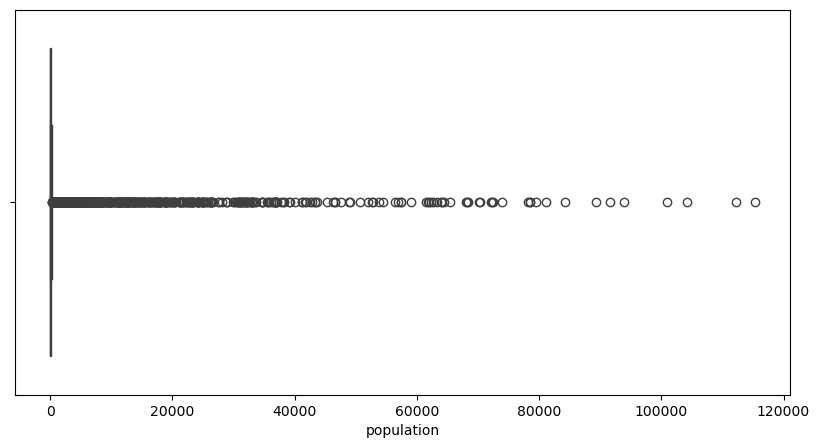

In [84]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df['population'])
plt.show()

The population variable exhibited a highly right-skewed distribution with several extreme values. However, these observations likely represent genuine large-scale refugee populations rather than data entry errors. Therefore, no outlier removal was performed to preserve important humanitarian information and maintain forecasting accuracy.

In [85]:
# investigating the zeros
(df['population'] == 0).sum()

3782

In [86]:
(df['population'] == 0).mean()*100

44.285714285714285

Approximately 40.47% of the observations have a population value of zero. Given the nature of humanitarian and refugee population data, these zero values may represent legitimate cases where no individuals were recorded in a particular category rather than missing data. Further investigation is required to determine whether these zeros are valid observations or potential reporting issues.

In [87]:
# Examine the distribution of zero population values across population groups
df[df['population'] == 0]['population_group'].value_counts()

population_group
ASY    2084
REF    1498
OOC     140
HST      60
Name: count, dtype: int64

The zero values will be retained because they appear across several population groups and may represent legitimate instances where no individuals were recorded during a reporting period.

In [88]:
# Examine the distribution of zero population values across gender categories
df[df['population'] == 0]['gender'].value_counts()

gender
f    1971
m    1811
Name: count, dtype: int64

Zero population values are relatively evenly distributed between female and male categories. This suggests that the occurrence of zeros is not biased toward a particular gender and is unlikely to be the result of gender-specific reporting errors. No action will be taken on the basis of gender distribution, and the zero values will be retained for further analysis.

In [89]:
# Examine the distribution of zero population values across age groups
df[df['population'] == 0]['age_range'].value_counts()

age_range
60+      1017
0-4       852
12-17     733
5-11      728
18-59     452
Name: count, dtype: int64

Zero population values are observed across all age groups, with the largest number occurring among children aged 0–4 years. Since the zeros are spread throughout the age categories rather than concentrated in a single group, they are more likely to represent valid observations than systematic data errors. The zero values will be retained because there is no evidence that they are caused by age-specific reporting problems.

In [90]:
# Verify that the date columns were converted successfully
df[['reference_period_start','reference_period_end']].dtypes

reference_period_start    datetime64[ns]
reference_period_end      datetime64[ns]
dtype: object

In [91]:
# Visualizing the distribution of population values to assess skewness and identify extreme observations
#plt.figure(figsize=(10,5))
#sns.histplot(df['population'], bins=50)
#plt.show()

The histogram shows that the population variable is highly right-skewed. Most observations are concentrated at very low population values, while a relatively small number of observations have extremely large population counts. This pattern is consistent with refugee and displacement data, where many demographic groups may have few or no recorded individuals, while a few groups account for very large populations.

In [92]:
# Display the unique population group categories in the dataset
df['population_group'].unique()

array(['ASY', 'REF', 'HST', 'OOC'], dtype=object)

In [93]:
# Display the unique gender categories in the dataset
df['gender'].unique()

array(['f', 'm'], dtype=object)

In [94]:
# Display the unique age range categories in the dataset
df['age_range'].unique()

array(['0-4', '5-11', '12-17', '18-59', '60+'], dtype=object)

In [95]:
df[['age_range','min_age','max_age']].isnull().sum()

age_range       0
min_age         0
max_age      1708
dtype: int64

**6. EXPLORATORY DATA ANALYSIS**

**UNIVARIATE ANALYSIS**

The variables in the dataset all are all categorical variables and are repeated throughout the dataset. They therefore appear the same number of times thtoughut the dataset. This applies to all the varianles except the population column. The best approach to EDA is bivariate analysis.

<Axes: ylabel='count'>

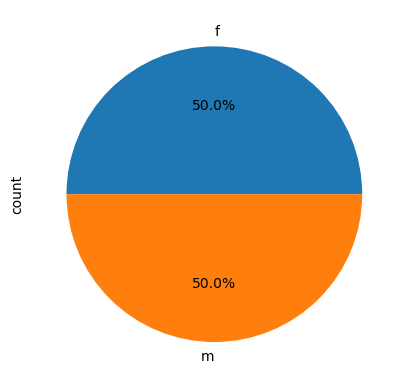

In [96]:
#Plotting a pie chart to show the distribution of gender categories

df['gender'].value_counts().plot(kind='pie', autopct='%1.1f%%')

The pie chart showsthat there is a balanced disttribution of both genders as represented in the dataset.

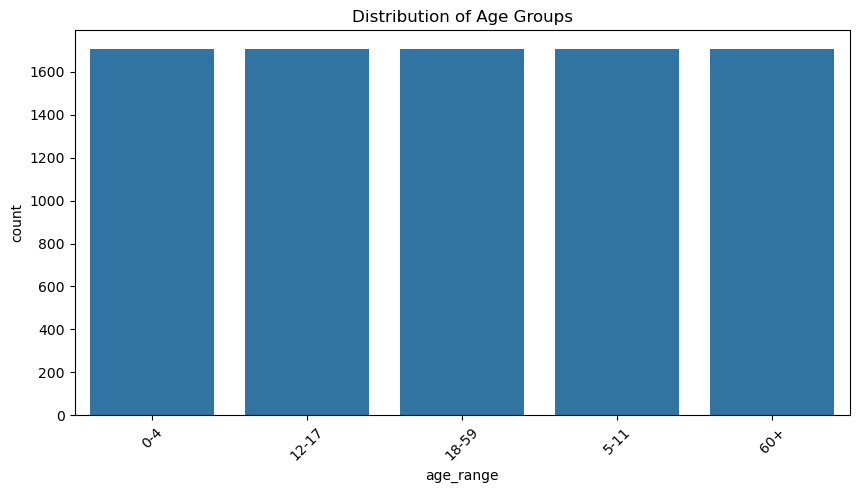

In [97]:
plt.figure(figsize=(10,5))

sns.countplot(df,x="age_range",
              order=sorted(df["age_range"].unique()))

plt.title("Distribution of Age Groups")

plt.xticks(rotation=45)

plt.show()

The graph shows that there is a balanced disttribution of all the age ranges as represented in the dataset.

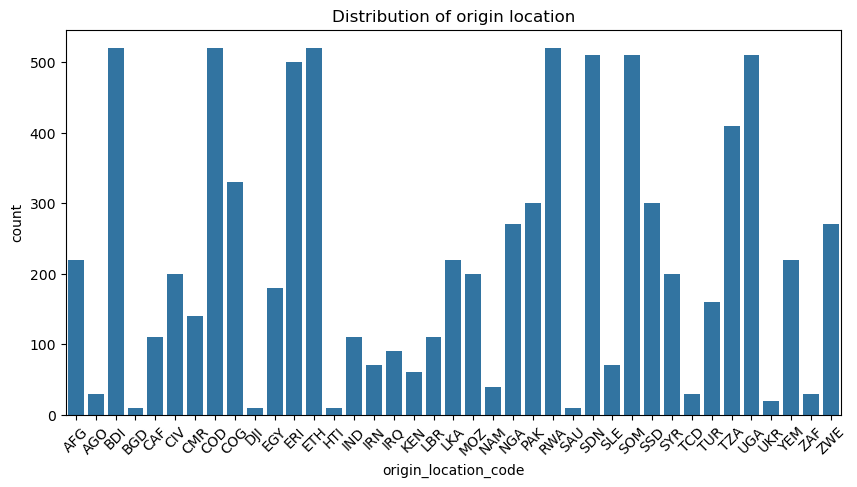

In [98]:
plt.figure(figsize=(10,5))

sns.countplot(df,x="origin_location_code",
              order=sorted(df["origin_location_code"].unique()))

plt.title("Distribution of origin location")

plt.xticks(rotation=45)

plt.show()

#Interpretation for the above graph

In [99]:
df.head()

,origin_location_code,origin_has_hrp,origin_in_gho,asylum_location_code,asylum_has_hrp,asylum_in_gho,population_group,gender,age_range,min_age,max_age,population,reference_period_start,reference_period_end
0,AFG,True,True,KEN,False,True,ASY,f,0-4,0.0,4.0,0,2020-01-01,2020-12-31
1,AFG,True,True,KEN,False,True,ASY,f,5-11,5.0,11.0,0,2020-01-01,2020-12-31
2,AFG,True,True,KEN,False,True,ASY,f,12-17,12.0,17.0,0,2020-01-01,2020-12-31
3,AFG,True,True,KEN,False,True,ASY,f,18-59,18.0,59.0,0,2020-01-01,2020-12-31
4,AFG,True,True,KEN,False,True,ASY,f,60+,60.0,NaN,0,2020-01-01,2020-12-31


In [100]:
#Plotting a pie chart




**BIVARIATE ANALYSIS**

<function matplotlib.pyplot.show(close=None, block=None)>

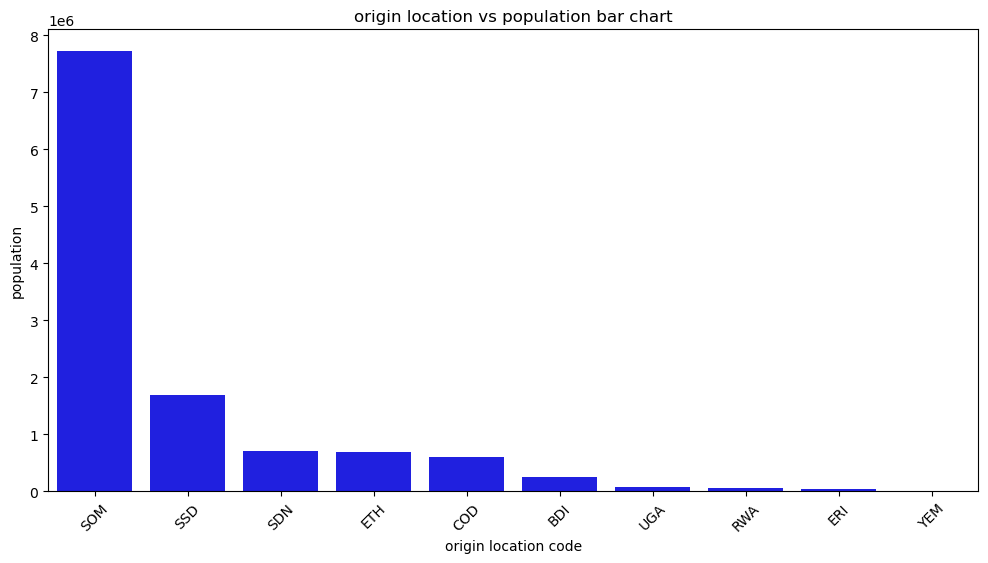

In [101]:
#A graph of countries against the population. This is to show where most refugees have come from across the dataset.

#Grouping origin location codes and finding the total population for each one of them.
country_population = (
    df.groupby('origin_location_code')['population']
        .sum()
        .reset_index()
)

top_10 = (
    country_population
    .sort_values(by = 'population', ascending = False)
    .head(10)
)
                 
#Plotting the bar based on the grouped data above.
plt.figure(figsize=(12,6))

sns.barplot(data=top_10, x= 'origin_location_code', y = 'population', color='blue')

plt.title("origin location vs population bar chart")
plt.xlabel("origin location code")
plt.ylabel("population")
plt.xticks(rotation=45)
plt.show


**Interepretation of the origin location vs population graph**

Based on the above bar chart, the maximum refugees that end up in Kenya are from Somalia,followed by Southsudan by a very big distance followed by Sudan,Ethiopia and Congo. This is to say that Kenyan refugees comes from the immediate neignbbouring countries rather than countries that involve crossing multiple borders to get to Kenya.

In [102]:
#Running the dataframe for visibility
df.head()

,origin_location_code,origin_has_hrp,origin_in_gho,asylum_location_code,asylum_has_hrp,asylum_in_gho,population_group,gender,age_range,min_age,max_age,population,reference_period_start,reference_period_end
0,AFG,True,True,KEN,False,True,ASY,f,0-4,0.0,4.0,0,2020-01-01,2020-12-31
1,AFG,True,True,KEN,False,True,ASY,f,5-11,5.0,11.0,0,2020-01-01,2020-12-31
2,AFG,True,True,KEN,False,True,ASY,f,12-17,12.0,17.0,0,2020-01-01,2020-12-31
3,AFG,True,True,KEN,False,True,ASY,f,18-59,18.0,59.0,0,2020-01-01,2020-12-31
4,AFG,True,True,KEN,False,True,ASY,f,60+,60.0,NaN,0,2020-01-01,2020-12-31


<function matplotlib.pyplot.show(close=None, block=None)>

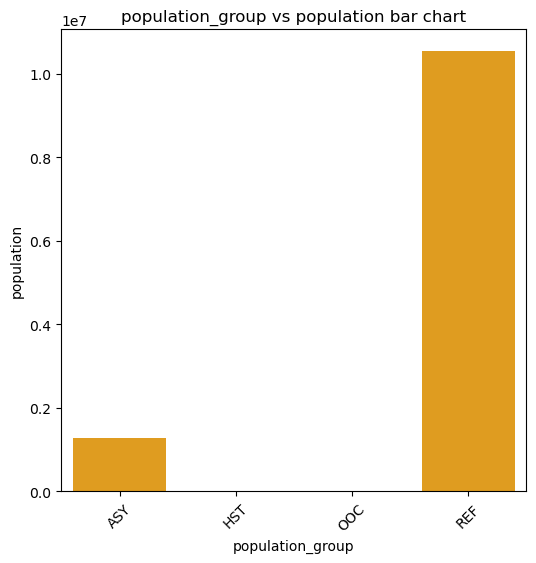

In [103]:
#The plot below is for population group which is either asylum or refugee etc against population

#creating a variable which groups the data by population group and computes the total population of each.
population_g_population = (
    df.groupby('population_group')['population']
        .sum()
        .reset_index()
)

#Plotting the bar graph
plt.figure(figsize=(6,6))

sns.barplot(data=population_g_population, x= 'population_group', y = 'population', color='orange')

plt.title("population_group vs population bar chart")
plt.xlabel("population_group")
plt.ylabel("population")
plt.xticks(rotation=45)
plt.show

**Interepretation of the origin location vs population graph**

The bar graph stresses on 2 categories which is Refugee and Asylum. With refugees being the people who receive their official status of being refugees while int heir origin country while asylum seekers receive their official status while already in the destination country.

However it is, the refugees are the majority 10-foled. This is a good indicator for humanitarian organizations in resource planning as most individuals are already identified while they are still in their country of origin. This gives lead time before they arrive in the destination country.

The other 2 categories are for Host Community and Others of Concern. These form a very negligible part of the data and aren't expected to have much impact on the final models.

<function matplotlib.pyplot.show(close=None, block=None)>

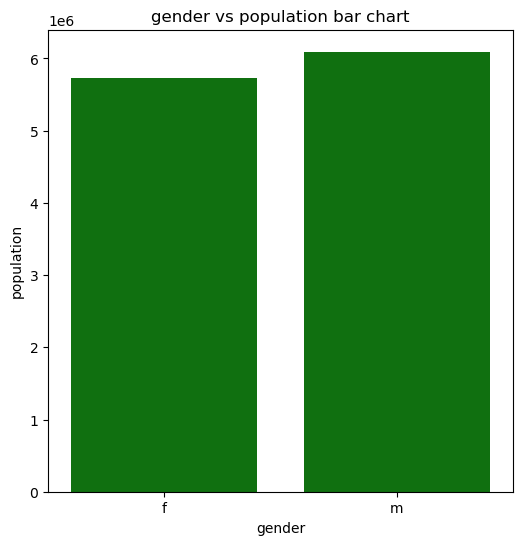

In [104]:
#Plotting a bar chart for geneder against population

#Creating a variable to group data by the gender and finding the sum of each of them.
gender_population = (
    df.groupby('gender')['population']
        .sum()
        .reset_index()
)

#Plotting the figure

plt.figure(figsize=(6,6))

sns.barplot(data=gender_population, x= 'gender', y = 'population', color='green')

plt.title("gender vs population bar chart")
plt.xlabel("gender")
plt.ylabel("population")
#plt.xticks(rotation=45)
plt.show

**Interepretation of the graph**

The population between the genders is a bit balanced. The population is therefore not skewed towards a particular gender.

<function matplotlib.pyplot.show(close=None, block=None)>

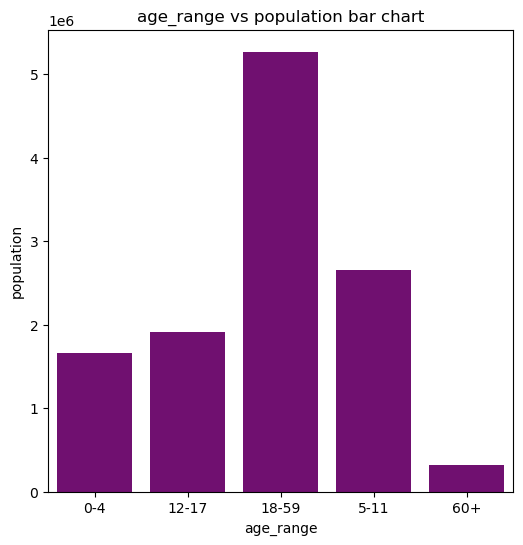

In [105]:
#Plotting a baer chart for age range against population

#Grouping age range and getting the total of population for each category
age_range_population = (
    df.groupby('age_range')['population']
        .sum()
        .reset_index()
)

#Plotting the figure

plt.figure(figsize=(6,6))

sns.barplot(data=age_range_population, x= 'age_range', y = 'population', color='purple')

plt.title("age_range vs population bar chart")
plt.xlabel("age_range")
plt.ylabel("population")
#plt.xticks(rotation=45)
plt.show

**Interepretation of the graph**

The dominant age range is from 18-59, which is an expected occurence as that range is wide compared to the rest.

<function matplotlib.pyplot.show(close=None, block=None)>

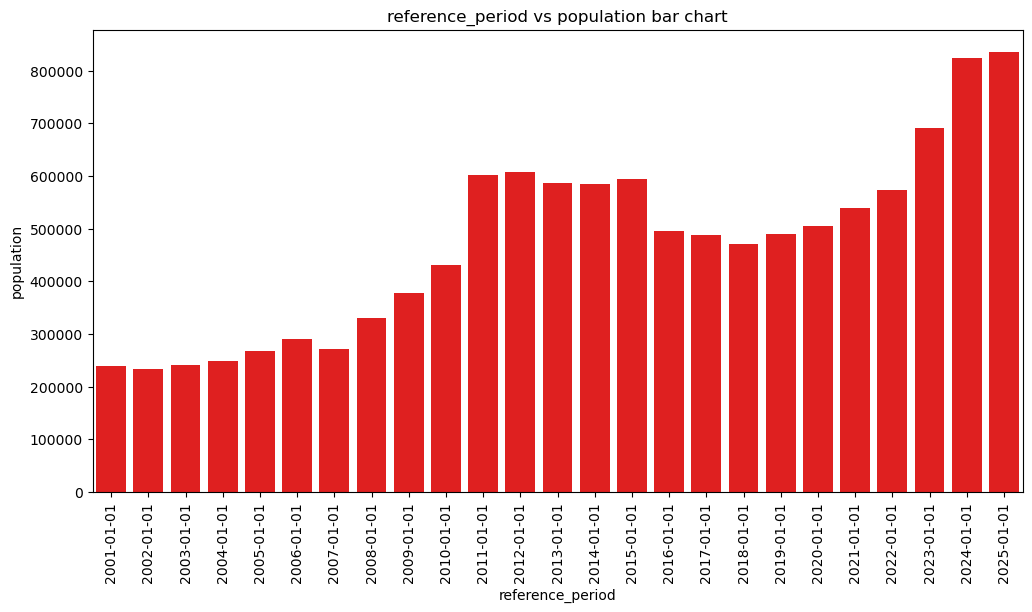

In [106]:
#Plotting a bar chart for the reference years against population

#Grouping the data based on years and then finding the sum of each.
period_population = (
    df.groupby('reference_period_start')['population']
        .sum()
        .reset_index()
)

#Plotting thebar

plt.figure(figsize=(12,6))

sns.barplot(data=period_population, x= 'reference_period_start', y = 'population', color='red')

plt.title("reference_period vs population bar chart")
plt.xlabel("reference_period")
plt.ylabel("population")
plt.xticks(rotation=90)
plt.show

**Interepretation of the graph**

Over the period starting from 2001 to date there has been a steady increase in the number of refugees that come to Kenya, there was a slight drop off in 2016-17 which was followed by a steady increase all the way to 2025. There has to be an expectation that the numbers will go even higher in the coming medium term.

**MULTIVARIATE ANALYSIS**

Multivariate analysis examines relationships among three or more variables simultaneously. This helps uncover complex demographic patterns that may not be visible through univariate or bivariate analysis.

For humanitarian organizations, understanding how age, gender, country of origin, and population interact is essential for effective resource planning and forecasting.

**Age Range, Gender and Population**

### Business Question

How is the refugee population distributed across different age groups and genders?

Understanding the demographic composition of refugee populations can help humanitarian agencies allocate healthcare, education, protection services, and livelihood programs more effectively.

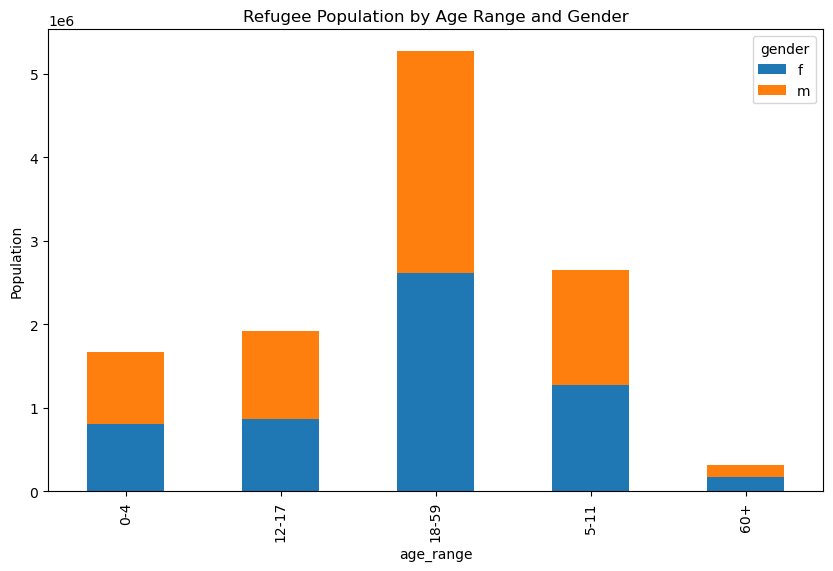

In [107]:
age_gender = pd.pivot_table(
    df,
    values='population',
    index='age_range',
    columns='gender',
    aggfunc='sum'
)

age_gender.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title('Refugee Population by Age Range and Gender')
plt.ylabel('Population')
plt.show()

### Observation

The refugee population is concentrated within specific age groups across both genders, with the working-age population accounting for the largest share.

### Business Insight

A large concentration of refugees within school-going age groups may indicate increased demand for educational facilities, while high populations within the working-age category may require employment and livelihood support interventions.

**Country of Origin, Gender and Population**

### Business Question

How does gender composition vary across refugee-producing countries?

Understanding gender patterns across countries of origin helps humanitarian agencies identify vulnerable populations and design targeted interventions.

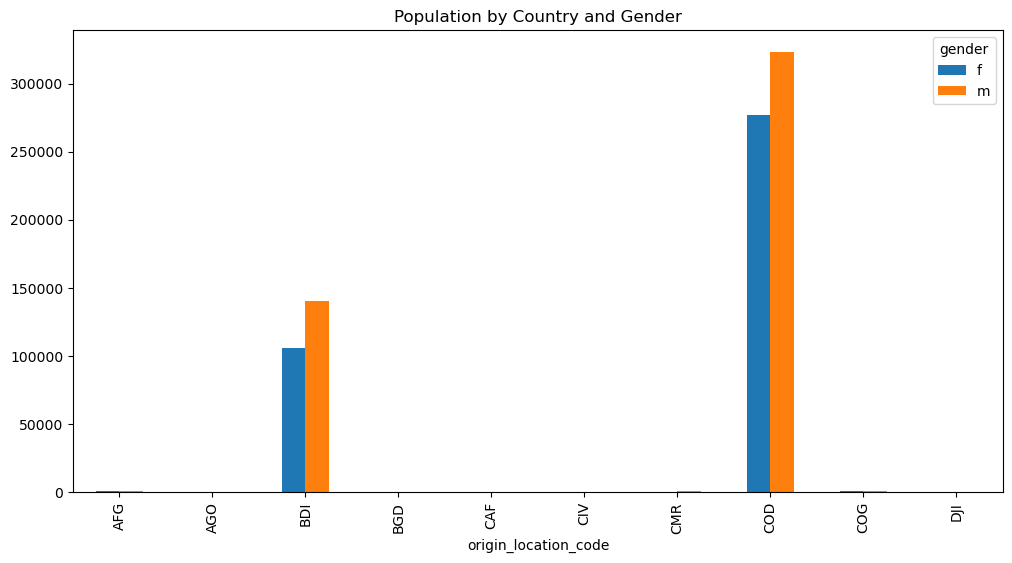

In [108]:
country_gender = pd.pivot_table(
    df,
    values='population',
    index='origin_location_code',
    columns='gender',
    aggfunc='sum'
)

country_gender.head(10).plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Population by Country and Gender')
plt.show()

### Observation

Gender distributions vary across countries of origin, reflecting different migration patterns and displacement dynamics.

### Business Insight

Country-specific demographic patterns can help humanitarian agencies prioritize interventions for vulnerable population segments.

Some countries contribute substantially larger refugee populations than others. Gender distributions may also vary across countries depending on migration patterns, conflict dynamics, and household structures.


**Population Group, Age Range and Population**

### Business Question

How are different population groups distributed across age categories?

Understanding age composition within population groups helps humanitarian agencies estimate future education, healthcare, and protection needs.

In [109]:
!pip install squarify

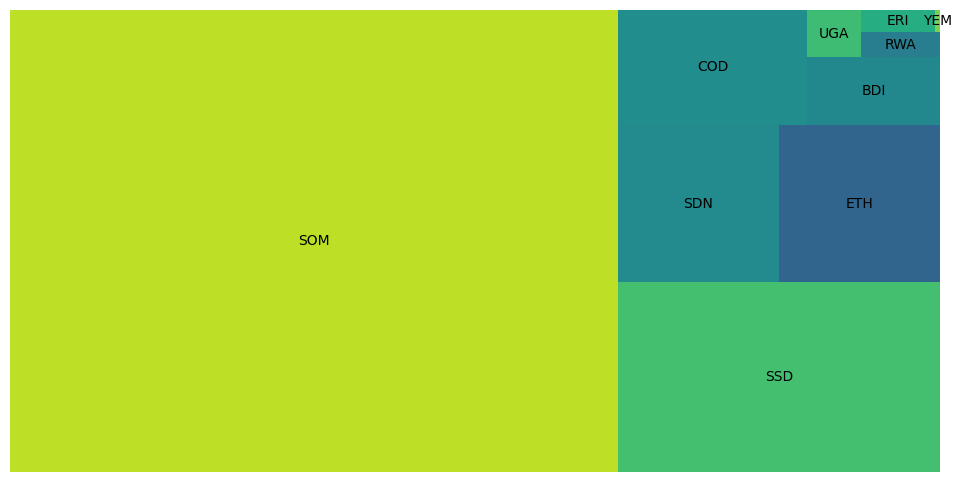

In [110]:

import squarify

country_pop = (
    df.groupby('origin_location_code')['population']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

squarify.plot(
    sizes=country_pop.values,
    label=country_pop.index
)

plt.axis('off')
plt.show()

### Observation

The analysis reveals how refugee populations are distributed across age groups within different population categories.

Certain population groups may contain disproportionately high numbers of children or working-age adults, indicating varying humanitarian needs.

### Business Insight

Population groups dominated by children may require increased investment in education and child protection services, while groups dominated by adults may require livelihood and employment support.

**Year of Assylum, Country of Origin and Population**

In [111]:
df['year'] = df['reference_period_start'].dt.year

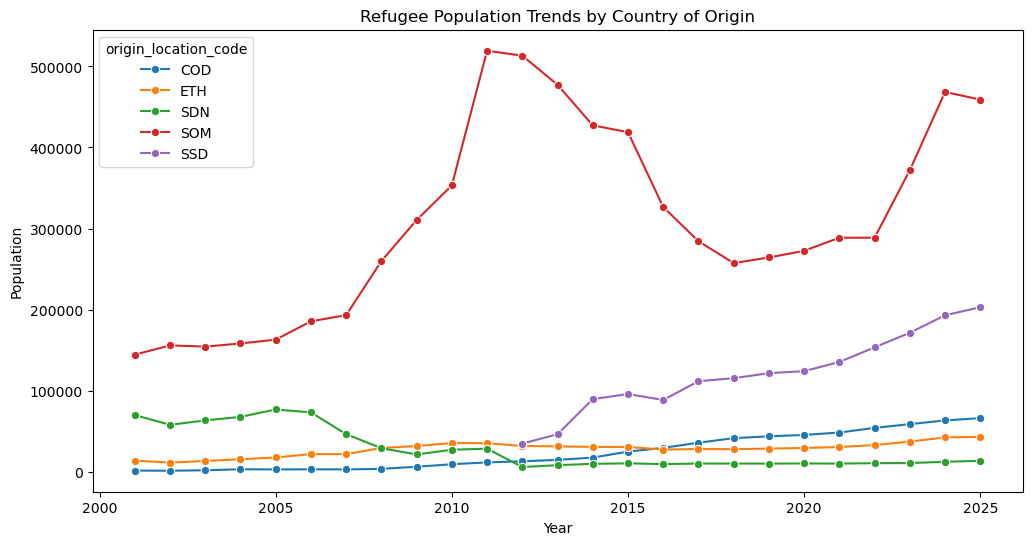

In [112]:
top_countries = (
    df.groupby('origin_location_code')['population']
      .sum()
      .nlargest(5)
      .index
)

year_country = (
    df[df['origin_location_code'].isin(top_countries)]
      .groupby(['year','origin_location_code'])['population']
      .sum()
      .reset_index()
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=year_country,
    x='year',
    y='population',
    hue='origin_location_code',
    marker='o'
)

plt.title('Refugee Population Trends by Country of Origin')
plt.xlabel('Year')
plt.ylabel('Population')

plt.show()

### Observation

The line chart shows how refugee populations from the major countries of origin have changed over time. While some countries exhibit relatively stable trends, others experience significant fluctuations that may be linked to conflict, political instability, economic challenges, or environmental crises.

These trends demonstrate that refugee inflows are not constant and reinforce the need for predictive models that can anticipate future population changes.

### Business Insight

Monitoring historical population trends from major refugee-producing countries enables humanitarian agencies to identify emerging displacement patterns and prepare resources proactively. Countries showing rapid population growth should receive closer attention because future increases may place additional pressure on food assistance, shelter capacity, healthcare services, and educational infrastructure in Kenya.

# Exploratory Data Analysis Summary

The exploratory data analysis provided valuable insights into refugee population dynamics in Kenya.

Key findings include:

- Refugee populations are unevenly distributed, with a few demographic groups and countries contributing the largest populations.
- The working-age population (18–59 years) forms the largest age segment among refugees hosted in Kenya.
- Both male and female refugees contribute significantly to the overall population.
- Refugee populations originate from multiple countries, although a small number of countries account for the majority of refugee inflows.
- Population trends vary over time, highlighting the dynamic nature of displacement and the importance of predictive analytics.
- Demographic patterns differ across age groups, genders, and countries of origin, suggesting varying humanitarian needs.

These findings provide a strong foundation for feature engineering and predictive modeling. The identified demographic and temporal patterns will support the development of machine learning models capable of forecasting refugee population changes and improving humanitarian resource planning in Kenya.